# Topic agenda results

This notebook presents saved results from [15_topic_agenda_calculations.ipynb](15_topic_agenda_calculations.ipynb). The default `ATTENTION_MODEL='spline'` is primary; select `power_law` for sensitivity analysis. Choose one distance metric at the top; the default is cosine. `NORMALIZE_REFERENCE_GAINS=False` is selected here to show raw gains toward article versus relative-votes targets.

The notebook performs no expensive distribution, metric, or oracle calculations. If a required artifact is missing, rerun notebook 15.

**Conditional estimand:** topic distributions describe only passages/comments assigned a valid topic by the development article-trained model. Unassigned material is excluded and assigned mass is renormalized. Alignment results therefore concern the classifiable portion of eligible stories, not the entire article or discussion. Assigned-exposure coverage should be read alongside every policy comparison.


Select the topic run in notebook 14, or pin `TOPIC_RUN_ID` below. Calculations and figures stay under the selected run's `analysis/` directory. Set `LEGACY_TOPIC_ROOT` explicitly to use an older unregistered fit.

Calculation manifests are checked against the current topic-modeling, metric, policy, and pin/reply code. Set `ALLOW_OLDER_RUN_RESULTS=True` only when intentionally viewing a compatible historical calculation; stored provenance remains unchanged. Missing random-reference gains always require rerunning notebook 15.


In [1]:
# The empirical spline is primary; both parametric models are fitted sensitivities.
ATTENTION_MODEL = 'spline'  # 'spline' or 'power_law'
ATTENTION_LABELS = {
    'spline': 'Smoothed empirical attention (primary)',
    'power_law': 'Fitted power-law attention (sensitivity)',
}
if ATTENTION_MODEL not in ATTENTION_LABELS:
    raise ValueError(f'ATTENTION_MODEL must be one of {list(ATTENTION_LABELS)}')
PREFIX = f'vote_{ATTENTION_MODEL}_'
ATTENTION_LABEL = ATTENTION_LABELS[ATTENTION_MODEL]
NORMALIZE_REFERENCE_GAINS = False  # Show raw gains toward article versus relative-votes targets.
DISTANCE_METRIC = 'cosine'  # 'jsd' or 'cosine'
DISTANCE_METRIC_CONFIG = {
    'jsd': {
        'metric_column': 'js_raw_target_gain',
        'metric_label': 'Discussion-Article Agenda Alignment',
        'x_label': 'Average effect on Jensen-Shannon gain',
        'metric_stem': 'article_js_gain',
        'gain_column': 'js_raw_target_gain',
        'scatter_stem': 'js',
        'oracle_name': 'js_oracle',
    },
    'cosine': {
        'metric_column': 'cosine_raw_target_gain',
        'metric_label': 'Discussion-Article Agenda Alignment',
        'x_label': 'Average effect on cosine similarity gain',
        'metric_stem': 'article_cosine_gain',
        'gain_column': 'cosine_raw_target_gain',
        'scatter_stem': 'cosine',
        'oracle_name': 'cosine_oracle',
    },
}
if DISTANCE_METRIC not in DISTANCE_METRIC_CONFIG:
    raise ValueError("DISTANCE_METRIC must be one of: 'jsd', 'cosine'")


In [2]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

from commentgap_analysis.topic_policy import (
    build_policy_contrast_order,
)
from commentgap_analysis.topic_plotting import (
    article_oracle_target_gains,
    plot_combined_article_alignment_effects,
    plot_article_relative_votes_progress_scatter,
    plot_topic_policy_concentration_effects,
    plot_topic_policy_exposure_coverage,
)
from commentgap_analysis.forum_scores import policy_specs
from commentgap_analysis.topic_artifacts import (
    code_revision, file_sha256, input_signature, required, topic_calculation_artifacts,
    topic_calculation_config, topic_calculation_source_manifests, validate_topic_run,
)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'commentgap_analysis').exists() and (REPO_ROOT.parent / 'commentgap_analysis').exists():
    REPO_ROOT = REPO_ROOT.parent
from commentgap_analysis.topic_runs import resolve_run
RUNS_ROOT = REPO_ROOT / 'model_output/selection_2025/paper2_topic_runs'
TOPIC_RUN_ID = 'mcs15_nn10_ms5_seed2026_1e1b8fce5deb3e58'  # Final no-outlier-reduction model.
LEGACY_TOPIC_ROOT = None  # Set to the old artifact directory to explicitly use a legacy fit.
ALLOW_OLDER_RUN_RESULTS = True  # Opt in when inspecting a compatible older run.
TOPIC_ROOT = (Path(LEGACY_TOPIC_ROOT) if LEGACY_TOPIC_ROOT is not None
              else resolve_run(RUNS_ROOT, TOPIC_RUN_ID))
print('Using topic model:', TOPIC_ROOT)
OUTPUT_ROOT = TOPIC_ROOT / 'analysis'


MEMBERSHIP_PATH = TOPIC_ROOT / 'document_topic_memberships.parquet'
COMMENTS_PATH = REPO_ROOT / 'model_output/selection_2025/paper2/analysis_comments.parquet'
INPUT_SIGNATURE = input_signature(
    repo_root=REPO_ROOT, membership_path=MEMBERSHIP_PATH,
    comments_path=COMMENTS_PATH, topic_root=TOPIC_ROOT,
)
SCORE_POLICIES = {
    'chronological': None, 'reverse_chronological': None, 'relative_votes': None, 'upvotes': None,
    'random': None,
    'regression_audience': 'regression_audience_score', 'regression_editor': 'regression_editor_score',
    'xgb_metadata_audience': 'xgb_metadata_audience_score', 'xgb_metadata_editor': 'xgb_metadata_editor_score',
    'xgb_metadata_text_audience': 'xgb_metadata_text_audience_score', 'xgb_metadata_text_editor': 'xgb_metadata_text_editor_score',
    'neural_metadata_audience': 'neural_metadata_audience_score', 'neural_metadata_editor': 'neural_metadata_editor_score',
    'neural_metadata_text_audience': 'neural_metadata_text_audience_score', 'neural_metadata_text_editor': 'neural_metadata_text_editor_score',
}
from commentgap_analysis.presentation_labels import ORDERING_DISPLAY_LABELS
ORDERING_LABELS = dict(ORDERING_DISPLAY_LABELS)
REPLY_LABELS = {'loose': 'Loose replies', 'trees': 'Thread trees', 'hidden': 'Hidden replies'}
contrast_order = build_policy_contrast_order(SCORE_POLICIES)
ANALYSIS_MODELS = ('spline', 'power_law')
DISTANCE_MEASURES = ('cosine', 'jensen_shannon')
CALCULATION_CONFIG = topic_calculation_config(
    score_policies=SCORE_POLICIES, policy_specs=policy_specs(),
    analysis_models=ANALYSIS_MODELS, distance_measures=DISTANCE_MEASURES,
)
CALCULATION_CODE = {
    'topic_artifacts_code_hash': file_sha256(REPO_ROOT / 'commentgap_analysis/topic_artifacts.py'),
    'topic_modeling_code_hash': file_sha256(REPO_ROOT / 'commentgap_analysis/topic_modeling.py'),
    'topic_metrics_code_hash': file_sha256(REPO_ROOT / 'commentgap_analysis/topic_metrics.py'),
    'topic_policy_code_hash': file_sha256(REPO_ROOT / 'commentgap_analysis/topic_policy.py'),
    'forum_scores_code_hash': file_sha256(REPO_ROOT / 'commentgap_analysis/forum_scores.py'),
    'vote_attention_code_hash': file_sha256(REPO_ROOT / 'commentgap_analysis/vote_attention.py'),
    'code_revision': code_revision(),
}
CALCULATION_PROVENANCE = {
    'run_id': TOPIC_RUN_ID, 'inputs': INPUT_SIGNATURE,
    'config': CALCULATION_CONFIG, 'code': CALCULATION_CODE,
}
SCHEMA_CHECKS = {
    f'{model}_metrics': ('story_id', 'policy_id') for model in ANALYSIS_MODELS
}
SCHEMA_CHECKS.update({
    f'{model}_metrics_draws': ('story_id', 'policy_id', 'draw') for model in ANALYSIS_MODELS
})
validate_topic_run(
    OUTPUT_ROOT, expected_provenance=CALCULATION_PROVENANCE,
    required_artifacts=topic_calculation_artifacts(OUTPUT_ROOT),
    optional_artifacts=topic_calculation_source_manifests(OUTPUT_ROOT),
    schema_checks=SCHEMA_CHECKS,
    allow_older_results=ALLOW_OLDER_RUN_RESULTS, allow_legacy_missing=ALLOW_OLDER_RUN_RESULTS,
)
metrics = pd.read_parquet(required(OUTPUT_ROOT / f'topic_policy_{PREFIX}metrics.parquet'))
concentration_story = pd.read_parquet(required(OUTPUT_ROOT / f'{PREFIX}topic_policy_concentration_story_metrics.parquet'))
coverage_summary = pd.read_csv(required(OUTPUT_ROOT / f'{PREFIX}topic_policy_exposure_coverage_summary.csv'))
reference_target_metrics = pd.read_parquet(required(OUTPUT_ROOT / f'{PREFIX}topic_policy_reference_target_metrics.parquet'))
random_gains = reference_target_metrics.loc[
    reference_target_metrics.policy_id.eq('random__loose__unpinned'),
    ['js_raw_target_gain', 'cosine_raw_target_gain'],
]
if random_gains.empty or random_gains.isna().any().any():
    raise RuntimeError('Reference gains are missing the random baseline. Rerun notebook 15.')
if random_gains.abs().max().max() > 1e-10:
    if ALLOW_OLDER_RUN_RESULTS:
        print('Allowing older random-baseline gains under explicit override')
    else:
        raise RuntimeError('Reference gains use an outdated random baseline. Rerun notebook 15.')
cosine_oracle = pd.read_parquet(required(OUTPUT_ROOT / f'topic_policy_{PREFIX}cosine_oracle_metrics.parquet'))
js_oracle = pd.read_parquet(required(OUTPUT_ROOT / f'topic_policy_{PREFIX}js_oracle_metrics.parquet'))
DISTANCE_CONFIG = DISTANCE_METRIC_CONFIG[DISTANCE_METRIC]
DISTANCE_ORACLE = cosine_oracle if DISTANCE_METRIC == 'cosine' else js_oracle

Using topic model: /home/patrick/Documents/commentgap/model_output/selection_2025/paper2_topic_runs/mcs15_nn10_ms5_seed2026_1e1b8fce5deb3e58


## Coverage

Coverage is the share of the policy’s total rank attention weight carried by comments with valid topic assignments. It is shown alongside the alignment metrics so a policy that appears more article-aligned can be checked for whether that result is partly driven by which comments received topics.

,metric,label,mean,sd,ci_lower,ci_upper,n
0,article_discussion_js_distance,Article -discussion JS distance,0.4711,0.2105,0.4629,0.4793,2531
1,article_discussion_cosine_similarity,Article -discussion raw-proportion cosine simi...,0.6494,0.3622,0.6353,0.6636,2531
2,article_discussion_bhattacharyya_coefficient,Article -discussion Bhattacharyya coefficient ...,0.6390,0.2976,0.6275,0.6506,2531
3,article_normalized_entropy,Article normalized entropy,0.1141,0.0720,0.1112,0.1169,2531
4,discussion_normalized_entropy,Discussion normalized entropy,0.0787,0.0494,0.0767,0.0806,2531
5,discussion_minus_article_normalized_entropy,Discussion minus article normalized entropy,-0.0354,0.0876,-0.0388,-0.0320,2531
6,article_effective_topic_count,Article effective topic count,2.2092,1.0338,2.1689,2.2495,2531
7,discussion_effective_topic_count,Discussion effective topic count,1.6919,0.5486,1.6705,1.7132,2531
8,discussion_minus_article_effective_topic_count,Discussion minus article effective topic count,-0.5174,1.1863,-0.5636,-0.4711,2531


,metric,label,mean,sd,ci_lower,ci_upper,n,n_stories,mean_sample_size
0,article_normalized_entropy,Rarefied article normalized entropy,0.1136,0.0721,0.1133,0.1139,253100,2531,10.1193
1,discussion_normalized_entropy,Rarefied discussion normalized entropy,0.0514,0.0576,0.0512,0.0516,253100,2531,10.1193
2,discussion_minus_article_normalized_entropy,Rarefied discussion minus article normalized e...,-0.0622,0.0929,-0.0625,-0.0618,253100,2531,10.1193
3,article_effective_topic_count,Rarefied article effective topic count,2.2034,1.0327,2.1994,2.2074,253100,2531,10.1193
4,discussion_effective_topic_count,Rarefied discussion effective topic count,1.4609,0.5821,1.4586,1.4632,253100,2531,10.1193
5,discussion_minus_article_effective_topic_count,Rarefied discussion minus article effective to...,-0.7425,1.2044,-0.7472,-0.7378,253100,2531,10.1193


,policy_id,ordering,reply_mode,pinned,n_stories,assigned_exposure_coverage_mean,assigned_exposure_coverage_sd,alignment_gain_mean,alignment_gain_sd,article_visible_js_distance_mean,article_visible_js_distance_sd
0,chronological__hidden__pinned,chronological,hidden,True,2530,0.2849,0.1535,0.0259,0.0628,0.4451,0.2182
1,chronological__hidden__unpinned,chronological,hidden,False,2530,0.2773,0.1446,0.0224,0.0615,0.4486,0.2183
2,chronological__loose__pinned,chronological,loose,True,2530,0.2685,0.1045,0.0056,0.0254,0.4654,0.2114
3,chronological__loose__unpinned,chronological,loose,False,2531,0.2638,0.0968,0.0015,0.0215,0.4697,0.2116
4,chronological__trees__pinned,chronological,trees,True,2530,0.2686,0.1044,0.0053,0.0259,0.4657,0.2115
...,...,...,...,...,...,...,...,...,...,...,...
85,xgb_metadata_text_editor__hidden__unpinned,xgb_metadata_text_editor,hidden,False,2530,0.2905,0.1603,0.0298,0.0661,0.4412,0.2184
86,xgb_metadata_text_editor__loose__pinned,xgb_metadata_text_editor,loose,True,2530,0.2703,0.1070,0.0073,0.0268,0.4637,0.2110
87,xgb_metadata_text_editor__loose__unpinned,xgb_metadata_text_editor,loose,False,2531,0.2701,0.1055,0.0069,0.0251,0.4642,0.2113
88,xgb_metadata_text_editor__trees__pinned,xgb_metadata_text_editor,trees,True,2530,0.2699,0.1066,0.0066,0.0266,0.4644,0.2110


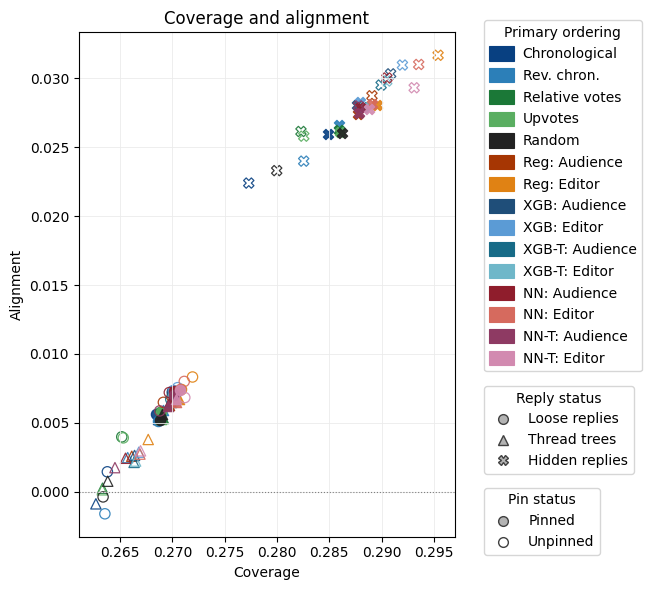

,policy_id,ordering,reply_mode,pinned,n_stories,assigned_exposure_coverage_mean,assigned_exposure_coverage_sd,alignment_gain_mean,alignment_gain_sd,article_visible_js_distance_mean,article_visible_js_distance_sd
0,chronological__hidden__pinned,chronological,hidden,True,2530,0.2849,0.1535,0.0259,0.0628,0.4451,0.2182
1,chronological__hidden__unpinned,chronological,hidden,False,2530,0.2773,0.1446,0.0224,0.0615,0.4486,0.2183
2,chronological__loose__pinned,chronological,loose,True,2530,0.2685,0.1045,0.0056,0.0254,0.4654,0.2114
3,chronological__loose__unpinned,chronological,loose,False,2531,0.2638,0.0968,0.0015,0.0215,0.4697,0.2116
4,chronological__trees__pinned,chronological,trees,True,2530,0.2686,0.1044,0.0053,0.0259,0.4657,0.2115
...,...,...,...,...,...,...,...,...,...,...,...
85,xgb_metadata_text_editor__hidden__unpinned,xgb_metadata_text_editor,hidden,False,2530,0.2905,0.1603,0.0298,0.0661,0.4412,0.2184
86,xgb_metadata_text_editor__loose__pinned,xgb_metadata_text_editor,loose,True,2530,0.2703,0.1070,0.0073,0.0268,0.4637,0.2110
87,xgb_metadata_text_editor__loose__unpinned,xgb_metadata_text_editor,loose,False,2531,0.2701,0.1055,0.0069,0.0251,0.4642,0.2113
88,xgb_metadata_text_editor__trees__pinned,xgb_metadata_text_editor,trees,True,2530,0.2699,0.1066,0.0066,0.0266,0.4644,0.2110


In [3]:
for name in ['topic_agenda_baseline_summary.csv', 'topic_agenda_rarefaction_summary.csv']:
    path = OUTPUT_ROOT / name
    if path.exists():
        display(pd.read_csv(path).round(4))
display(coverage_summary.round(4))
coverage_plot = plot_topic_policy_exposure_coverage(
    coverage_summary, output_root=OUTPUT_ROOT, ordering_labels=ORDERING_LABELS,
    output_prefix=PREFIX, exposure_label=ATTENTION_LABEL,
)
display(coverage_plot.round(4))

In [4]:
sensitivity_path = OUTPUT_ROOT / 'topic_policy_fitted_attention_sensitivity.csv'
if sensitivity_path.exists():
    display(pd.read_csv(sensitivity_path).round(4))

,ordering,reply_mode,pinned,js_distance,alignment_gain,attention_model,js_distance_primary,alignment_gain_primary,change_in_js_distance,change_in_alignment_gain
0,chronological,hidden,False,0.4469,0.0241,power_law,0.4486,0.0224,-0.0017,0.0017
1,chronological,hidden,True,0.4458,0.0252,power_law,0.4451,0.0259,0.0007,-0.0007
2,chronological,loose,False,0.4690,0.0021,power_law,0.4697,0.0015,-0.0006,0.0006
3,chronological,loose,True,0.4666,0.0044,power_law,0.4654,0.0056,0.0012,-0.0012
4,chronological,trees,False,0.4723,-0.0012,power_law,0.4720,-0.0009,0.0003,-0.0003
...,...,...,...,...,...,...,...,...,...,...
175,xgb_metadata_text_editor,hidden,True,0.4431,0.0279,spline,0.4431,0.0279,0.0000,0.0000
176,xgb_metadata_text_editor,loose,False,0.4642,0.0069,spline,0.4642,0.0069,0.0000,0.0000
177,xgb_metadata_text_editor,loose,True,0.4637,0.0073,spline,0.4637,0.0073,0.0000,0.0000
178,xgb_metadata_text_editor,trees,False,0.4689,0.0022,spline,0.4689,0.0022,0.0000,0.0000


## Topic concentration and metric effects

These figures and tables are generated from the story-level artifacts. The two metric panels use the same policy contrasts.

,policy_id,ordering,reply_mode,pinned,n_stories,normalized_entropy_mean,effective_topic_count_mean,normalized_entropy_change_vs_discussion_mean,normalized_entropy_change_vs_relative_votes_mean,effective_topic_count_change_vs_discussion_mean,effective_topic_count_change_vs_relative_votes_mean,normalized_entropy_sd,effective_topic_count_sd,normalized_entropy_change_vs_discussion_sd,normalized_entropy_change_vs_relative_votes_sd,effective_topic_count_change_vs_discussion_sd,effective_topic_count_change_vs_relative_votes_sd
0,chronological__hidden__pinned,chronological,hidden,True,2530,0.0563,1.4884,-0.0223,-0.0197,-0.2034,-0.1782,0.0524,0.5394,0.0337,0.0310,0.3672,0.3363
1,chronological__hidden__unpinned,chronological,hidden,False,2530,0.0575,1.4994,-0.0212,-0.0186,-0.1924,-0.1671,0.0528,0.5454,0.0342,0.0328,0.3716,0.3569
2,chronological__loose__pinned,chronological,loose,True,2530,0.0744,1.6506,-0.0042,-0.0016,-0.0411,-0.0159,0.0498,0.5460,0.0155,0.0147,0.1828,0.1707
3,chronological__loose__unpinned,chronological,loose,False,2531,0.0764,1.6693,-0.0023,0.0003,-0.0225,0.0027,0.0497,0.5486,0.0124,0.0144,0.1479,0.1722
4,chronological__trees__pinned,chronological,trees,True,2530,0.0746,1.6523,-0.0041,-0.0015,-0.0395,-0.0143,0.0499,0.5472,0.0154,0.0148,0.1801,0.1716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,xgb_metadata_text_editor__hidden__unpinned,xgb_metadata_text_editor,hidden,False,2530,0.0554,1.4772,-0.0233,-0.0207,-0.2145,-0.1893,0.0516,0.5279,0.0336,0.0317,0.3663,0.3453
86,xgb_metadata_text_editor__loose__pinned,xgb_metadata_text_editor,loose,True,2530,0.0742,1.6487,-0.0044,-0.0018,-0.0430,-0.0178,0.0498,0.5456,0.0154,0.0145,0.1795,0.1677
87,xgb_metadata_text_editor__loose__unpinned,xgb_metadata_text_editor,loose,False,2531,0.0751,1.6566,-0.0036,-0.0010,-0.0353,-0.0101,0.0495,0.5454,0.0115,0.0125,0.1395,0.1520
88,xgb_metadata_text_editor__trees__pinned,xgb_metadata_text_editor,trees,True,2530,0.0745,1.6514,-0.0042,-0.0016,-0.0404,-0.0151,0.0498,0.5469,0.0153,0.0145,0.1785,0.1664


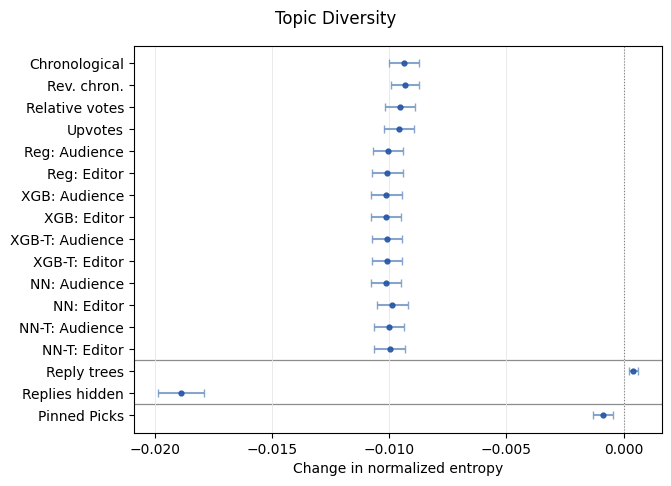

In [5]:
concentration_summary = pd.read_csv(required(OUTPUT_ROOT / f'{PREFIX}topic_policy_concentration_summary.csv'))
display(concentration_summary.round(4))
concentration_effects = plot_topic_policy_concentration_effects(
    concentration_story, contrast_order=contrast_order, output_root=OUTPUT_ROOT,
    ordering_labels=ORDERING_LABELS, reply_labels=REPLY_LABELS,
    output_stem=f'{PREFIX}topic_policy_concentration_effects',
)


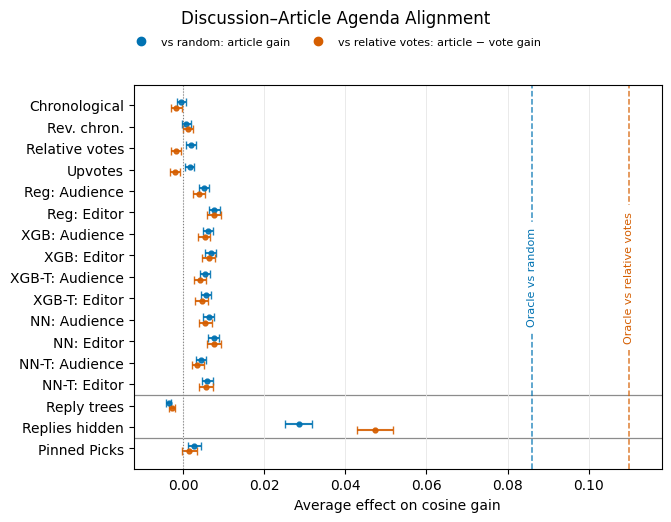

,series,family,contrast,label,mean,lower,upper,n
0,article,ordering_vs_random,chronological,Chronological,-0.0004,-0.0015,0.0007,2531
1,article,ordering_vs_random,reverse_chronological,Rev. chron.,0.0008,-0.0003,0.0018,2531
2,article,ordering_vs_random,relative_votes,Relative votes,0.0019,0.0007,0.0030,2531
3,article,ordering_vs_random,upvotes,Upvotes,0.0016,0.0005,0.0028,2531
4,article,ordering_vs_random,regression_audience,Reg: Audience,0.0051,0.0038,0.0064,2531
5,article,ordering_vs_random,regression_editor,Reg: Editor,0.0077,0.0063,0.0091,2531
6,article,ordering_vs_random,xgb_metadata_audience,XGB: Audience,0.0062,0.0049,0.0074,2531
7,article,ordering_vs_random,xgb_metadata_editor,XGB: Editor,0.0068,0.0054,0.0081,2531
8,article,ordering_vs_random,xgb_metadata_text_audience,XGB-T: Audience,0.0054,0.0041,0.0067,2531
9,article,ordering_vs_random,xgb_metadata_text_editor,XGB-T: Editor,0.0056,0.0043,0.0069,2531


In [6]:
# Both series use the same paired, averaged policy contrasts.
# Evaluate the article-optimising oracle separately on each plotted outcome.
if NORMALIZE_REFERENCE_GAINS:
    raise ValueError('The combined figure uses raw gains; set NORMALIZE_REFERENCE_GAINS=False.')
oracle_visible = pd.read_parquet(required(
    OUTPUT_ROOT / f'topic_policy_{PREFIX}{DISTANCE_CONFIG["oracle_name"]}_visible_distributions.parquet'
))
topic_columns = [c for c in oracle_visible if c.startswith('topic_') and c[6:].isdigit()]
relative_votes_visible = pd.read_parquet(
    required(OUTPUT_ROOT / f'topic_policy_{PREFIX}visible_distributions.parquet'),
    columns=['story_id', *topic_columns],
    filters=[('policy_id', '==', 'relative_votes__loose__unpinned')],
)
oracle_target_gains = article_oracle_target_gains(
    oracle_visible, relative_votes_visible, DISTANCE_ORACLE, reference_target_metrics,
    distance_metric=DISTANCE_METRIC,
)
combined_effects = plot_combined_article_alignment_effects(
    reference_target_metrics, oracle_target_gains,
    contrast_order=contrast_order, output_root=OUTPUT_ROOT,
    ordering_labels=ORDERING_LABELS, reply_labels=REPLY_LABELS,
    distance_metric=DISTANCE_METRIC, output_prefix=PREFIX,
)
display(combined_effects.round(4))


## Article and vote gains

Reference-target gains compare each policy with a random loose/unpinned presentation. The article target is its assigned-topic distribution; the relative-votes target is its mean assigned-topic distribution across tie draws.

With `NORMALIZE_REFERENCE_GAINS=True`, the marginal-effect figure compares the fractions of the two target gaps closed. This notebook defaults to `False` for raw gains. The scatter figures retain raw gains and their oracle markers use the same draw-averaged random baseline.


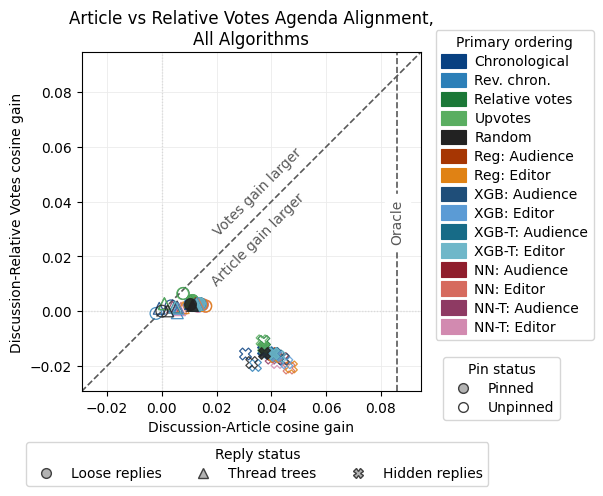

,policy_id,ordering,reply_mode,pinned,n_stories,cosine_gain_article,cosine_gain_relative_votes
0,chronological__hidden__pinned,chronological,hidden,True,2530,0.0371,-0.0142
1,chronological__hidden__unpinned,chronological,hidden,False,2530,0.0306,-0.0157
2,chronological__loose__pinned,chronological,loose,True,2530,0.0107,0.0028
3,chronological__loose__unpinned,chronological,loose,False,2531,0.0034,0.0019
4,chronological__trees__pinned,chronological,trees,True,2530,0.0102,0.0028
...,...,...,...,...,...,...,...
85,xgb_metadata_text_editor__hidden__unpinned,xgb_metadata_text_editor,hidden,False,2530,0.0430,-0.0167
86,xgb_metadata_text_editor__loose__pinned,xgb_metadata_text_editor,loose,True,2530,0.0137,0.0028
87,xgb_metadata_text_editor__loose__unpinned,xgb_metadata_text_editor,loose,False,2531,0.0127,0.0026
88,xgb_metadata_text_editor__trees__pinned,xgb_metadata_text_editor,trees,True,2530,0.0124,0.0027


In [7]:
scatter_summary = plot_article_relative_votes_progress_scatter(
    reference_target_metrics, metrics, DISTANCE_ORACLE, score_policies=SCORE_POLICIES,
    output_root=OUTPUT_ROOT, ordering_labels=ORDERING_LABELS, output_prefix=PREFIX,
    distance_metric=DISTANCE_METRIC,
)
scatter_display_columns = [
    'policy_id', 'ordering', 'reply_mode', 'pinned', 'n_stories',
    f"{DISTANCE_CONFIG['scatter_stem']}_gain_article",
    f"{DISTANCE_CONFIG['scatter_stem']}_gain_relative_votes",
]
display(scatter_summary[scatter_display_columns].round(4))

## Saved figures

All output paths below share the selected attention-model prefix. The CSV summaries beside them are the presentation tables used above.

In [8]:
figure_stems = [
    f'{PREFIX}topic_policy_exposure_coverage_relationship.png',
    f'{PREFIX}topic_policy_concentration_effects.png',
    f'{PREFIX}topic_policy_marginal_effects_{DISTANCE_CONFIG["metric_stem"]}.png',
    f'{PREFIX}topic_policy_article_vs_relative_votes_{"normalized" if NORMALIZE_REFERENCE_GAINS else "raw"}_gain_effects.png',
    f'{PREFIX}topic_policy_{DISTANCE_CONFIG["scatter_stem"]}_article_relative_votes_raw_gain_scatter.png',
]
for figure in figure_stems:
    path = OUTPUT_ROOT / figure
    if path.exists(): print(path)

/home/patrick/Documents/commentgap/model_output/selection_2025/paper2_topic_runs/mcs15_nn10_ms5_seed2026_1e1b8fce5deb3e58/analysis/vote_spline_topic_policy_exposure_coverage_relationship.png
/home/patrick/Documents/commentgap/model_output/selection_2025/paper2_topic_runs/mcs15_nn10_ms5_seed2026_1e1b8fce5deb3e58/analysis/vote_spline_topic_policy_concentration_effects.png
/home/patrick/Documents/commentgap/model_output/selection_2025/paper2_topic_runs/mcs15_nn10_ms5_seed2026_1e1b8fce5deb3e58/analysis/vote_spline_topic_policy_marginal_effects_article_cosine_gain.png
/home/patrick/Documents/commentgap/model_output/selection_2025/paper2_topic_runs/mcs15_nn10_ms5_seed2026_1e1b8fce5deb3e58/analysis/vote_spline_topic_policy_article_vs_relative_votes_raw_gain_effects.png
/home/patrick/Documents/commentgap/model_output/selection_2025/paper2_topic_runs/mcs15_nn10_ms5_seed2026_1e1b8fce5deb3e58/analysis/vote_spline_topic_policy_cosine_article_relative_votes_raw_gain_scatter.png
